# Exploratory Data Analysis (EDA)

## Objetivo
Entender o perfil dos clientes e seus padrões de comportamento financeiro
para apoiar a criação de um target de **valor estratégico do cliente**.

## Dataset
Base de clientes de cartão de crédito contendo informações demográficas,
comportamentais e financeiras.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
## Carregamento e visão geral

df = pd.read_csv("/home/tatiane/repositorios/data-projects/03_machine_learning/etl_customer_value_classfication/raw/data/BankChurners.csv")
df = df.drop(columns=['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'])

df.shape
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

- Informações observadas:
1. número de clientes: 10127
2. ausência de nulos
3. tipos de dados: int64, float64, object

In [7]:
## Estatística descritiva
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


Principais Insights

- Existe alta heterogeneidade (diferença) no comportamento financeiro dos clientes.
- Variáveis relacionadas a volume e frequência de transações apresentam grande dispersão.
- O limite de crédito também demonstra forte variação entre clientes.
- O dataset suporta a criação de um score de valor estratégico baseado em consumo e relacionamento.

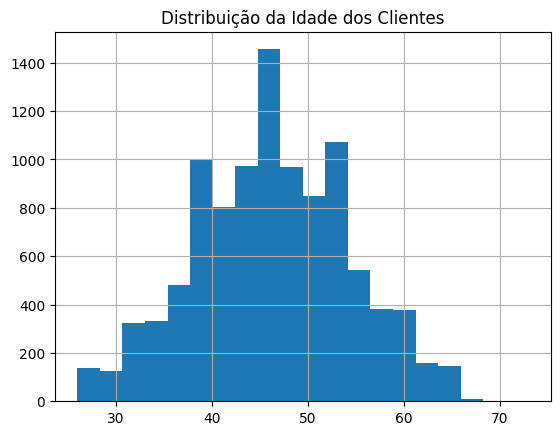

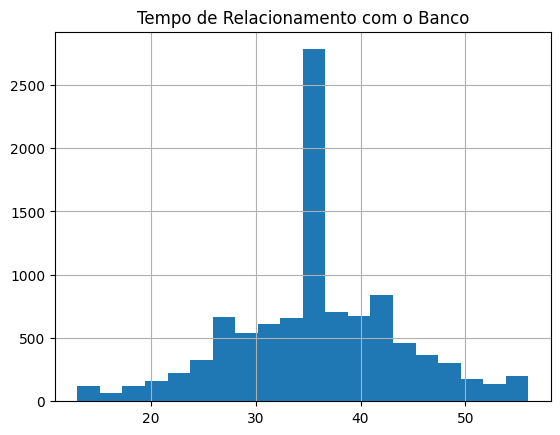

In [9]:
## Distribuições importantes
df["Customer_Age"].hist(bins=20)
plt.title("Distribuição da Idade dos Clientes")
plt.show()

df["Months_on_book"].hist(bins=20)
plt.title("Tempo de Relacionamento com o Banco")
plt.show()

### Análise financeira

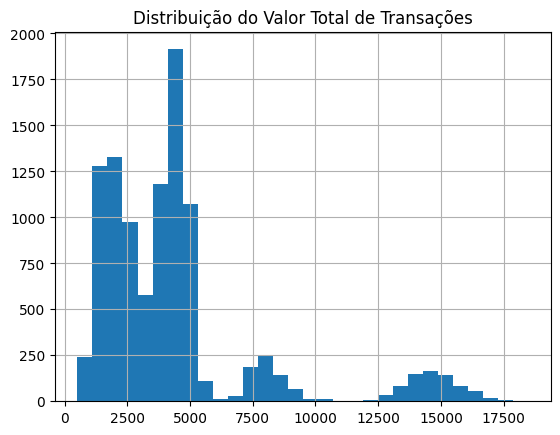

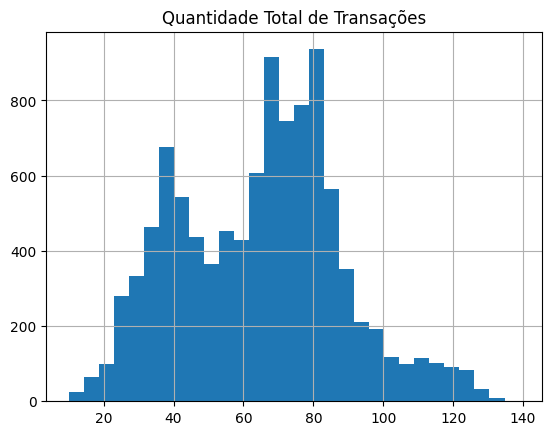

In [10]:
# Transações
df["Total_Trans_Amt"].hist(bins=30)
plt.title("Distribuição do Valor Total de Transações")
plt.show()

df["Total_Trans_Ct"].hist(bins=30)
plt.title("Quantidade Total de Transações")
plt.show()

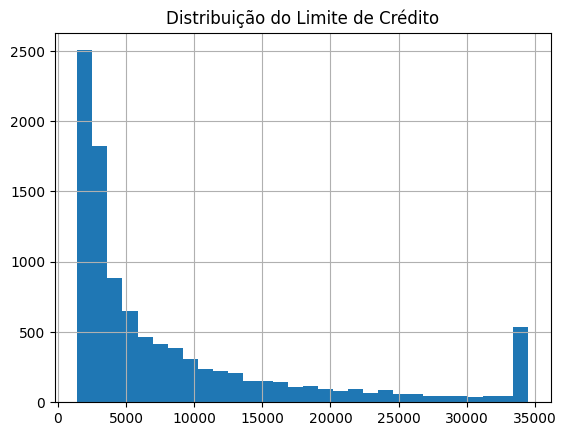

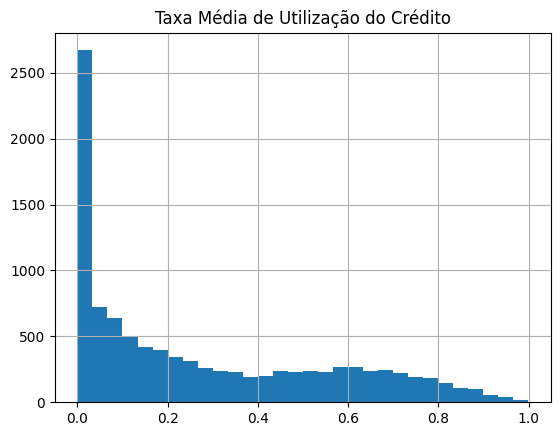

In [11]:
#Limite e utilização
df["Credit_Limit"].hist(bins=30)
plt.title("Distribuição do Limite de Crédito")
plt.show()

df["Avg_Utilization_Ratio"].hist(bins=30)
plt.title("Taxa Média de Utilização do Crédito")
plt.show()

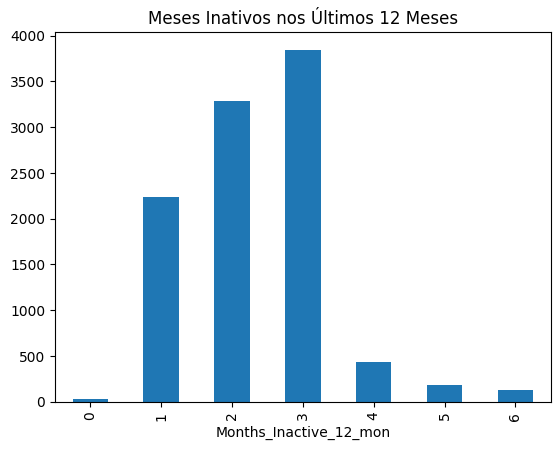

In [12]:
## Atividade vs inatividade
df["Months_Inactive_12_mon"].value_counts().sort_index().plot(kind="bar")
plt.title("Meses Inativos nos Últimos 12 Meses")
plt.show()

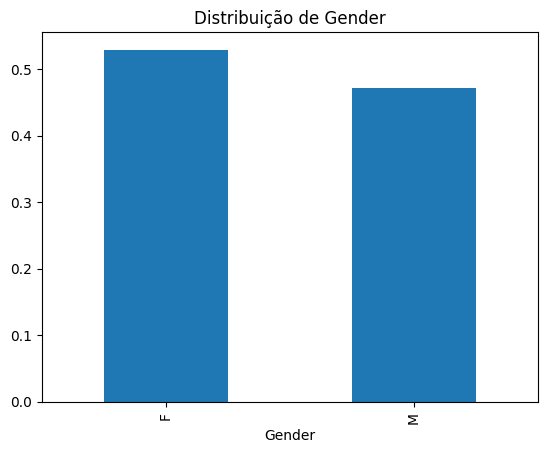

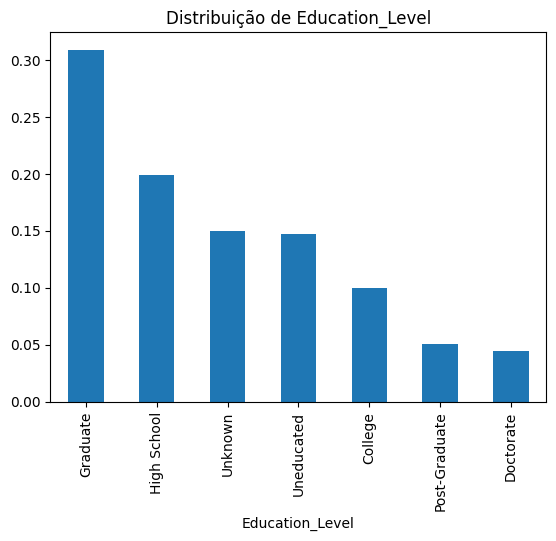

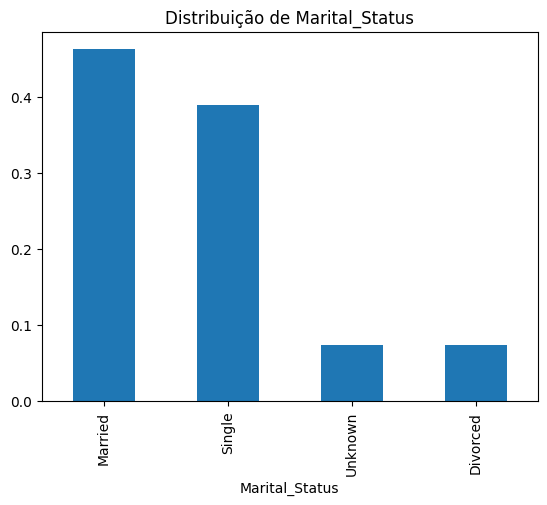

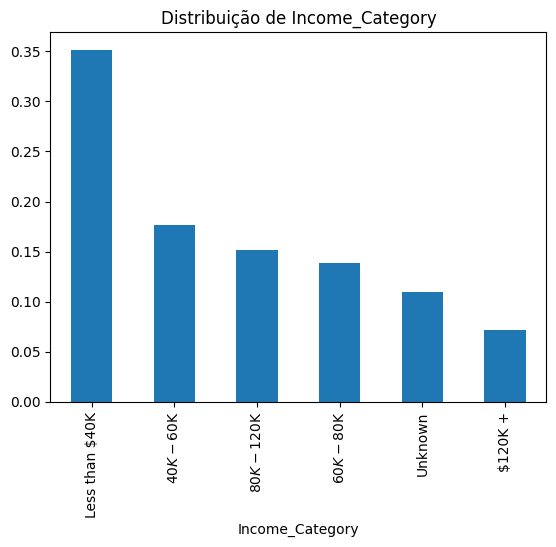

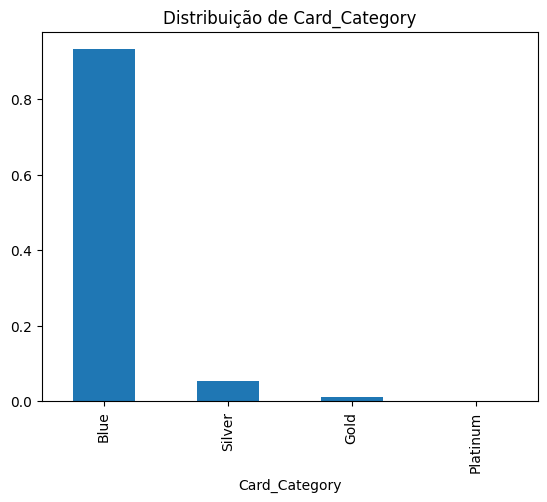

In [13]:
## Análise categórica
cat_cols = [
    "Gender",
    "Education_Level",
    "Marital_Status",
    "Income_Category",
    "Card_Category"
]

for col in cat_cols:
    df[col].value_counts(normalize=True).plot(kind="bar")
    plt.title(f"Distribuição de {col}")
    plt.show()

### Análise cruzada

In [14]:
df.groupby("Attrition_Flag")["Total_Trans_Amt"].mean()

Attrition_Flag
Attrited Customer    3095.025814
Existing Customer    4654.655882
Name: Total_Trans_Amt, dtype: float64

In [15]:
df.groupby("Attrition_Flag")["Months_Inactive_12_mon"].mean()

Attrition_Flag
Attrited Customer    2.693301
Existing Customer    2.273765
Name: Months_Inactive_12_mon, dtype: float64

### Correlação

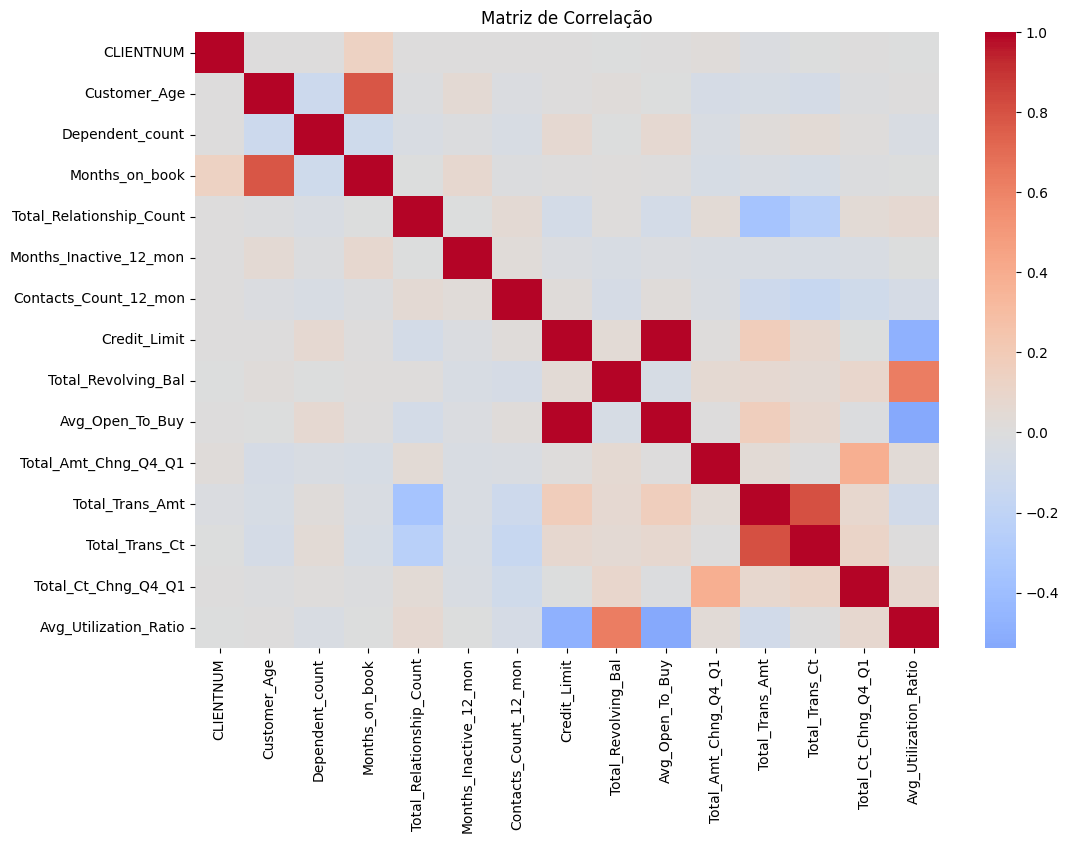

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Matriz de Correlação")
plt.show()

## Principais insights do EDA

- Observa-se alta variabilidade em Total_Trans_Amt e Credit_Limit, com distribuição assimétrica à direita, indicando concentração de clientes de baixo consumo e uma cauda de alto valor.
- Total_Trans_Amt e Total_Trans_Ct apresentam correlação de 0.85, indicando que clientes que transacionam mais frequentemente também movimentam maiores valores.
- Clientes com ≥3 meses (Months_Inactive_12_mon) de inatividade apresentam redução média de 37% no Total_Trans_Amt em comparação aos demais.